In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
import sklearn.metrics as metrics
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import optuna
import shap

In [26]:
df_accum = pd.read_csv('data/input_df_SUMMmet_accum.csv')

sites_to_drop = ['PTSH', 'SPST', 'SR01', 'SR25', 'SR11']
df_accum = df_accum[~df_accum['site.x'].isin(sites_to_drop)]

df_accum = df_accum[df_accum['delta'] < 40]

df_accum = df_accum.drop(['ant1d_SNOD', 'SNOD', 'date', 'X', 'Unnamed: 0', 'site.x', 'day', 'site.y'], axis = 1)

In [27]:
X_accum = df_accum.drop('delta', axis = 1)
y_accum = df_accum['delta']

X_accum_train, X_accum_test, y_accum_train, y_accum_test_1 = train_test_split(X_accum,
                                                                              y_accum,
                                                                              test_size=0.2, 
                                                                              random_state=4)

X_column_names = X_accum.columns
y_column_names = y_accum.name

scaler_X_accum = StandardScaler()
X_accum_fit = pd.DataFrame(scaler_X_accum.fit_transform(X_accum))
X_accum_fit.columns = X_column_names

y_accum_values = pd.DataFrame(y_accum).values

scaler_y_accum = StandardScaler()
y_accum_fit = pd.Series(scaler_y_accum.fit_transform(y_accum_values)[:,0])
y_accum_fit.name = y_column_names

In [ ]:
X_accum_fit_train, X_accum_fit_test, y_accum_fit_train, y_accum_fit_test = train_test_split(X_accum_fit,
                                                                                            y_accum_fit,
                                                                                            test_size=0.2, 
                                                                                            random_state=42)

In [17]:
accum_backprop = MLPRegressor(hidden_layer_sizes = [50],
                              activation = 'logistic',
                              learning_rate_init = 0.0005821050248398088,
                              alpha = 0.003921386524837973,
                              max_iter = 2000,
                              shuffle = False,
                              random_state = 42,
                              tol = 3.179785211748248e-07,
                              n_iter_no_change=38,
                              verbose = True,
                              learning_rate='adaptive',
                              solver = 'adam')

accum_backprop.fit(X_accum_fit_train, y_accum_fit_train)
preds_accum = accum_backprop.predict(X_accum_fit_test)

preds_accum = scaler_y_accum.inverse_transform(preds_accum.reshape(-1,1))
y_accum_test_2 = scaler_y_accum.inverse_transform(np.array(y_accum_fit_test).reshape(-1,1))

rmse_accum = metrics.root_mean_squared_error(y_accum_test_2, preds_accum)
r2_accum = metrics.r2_score(y_accum_test_2, preds_accum)



Iteration 1, loss = 0.50278606
Iteration 2, loss = 0.49260304
Iteration 3, loss = 0.48681691
Iteration 4, loss = 0.48319197
Iteration 5, loss = 0.48015996
Iteration 6, loss = 0.47721573
Iteration 7, loss = 0.47446905
Iteration 8, loss = 0.47205446
Iteration 9, loss = 0.46993676
Iteration 10, loss = 0.46800254
Iteration 11, loss = 0.46617427
Iteration 12, loss = 0.46443118
Iteration 13, loss = 0.46277484
Iteration 14, loss = 0.46120339
Iteration 15, loss = 0.45970985
Iteration 16, loss = 0.45828840
Iteration 17, loss = 0.45693593
Iteration 18, loss = 0.45564954
Iteration 19, loss = 0.45442482
Iteration 20, loss = 0.45325642
Iteration 21, loss = 0.45213918
Iteration 22, loss = 0.45106885
Iteration 23, loss = 0.45004203
Iteration 24, loss = 0.44905590
Iteration 25, loss = 0.44810804
Iteration 26, loss = 0.44719625
Iteration 27, loss = 0.44631846
Iteration 28, loss = 0.44547264
Iteration 29, loss = 0.44465683
Iteration 30, loss = 0.44386913
Iteration 31, loss = 0.44310774
Iteration 32, los

c:\Users\jrladue\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


rmse =  3.875621162277572
r2 =  0.7047432460913919


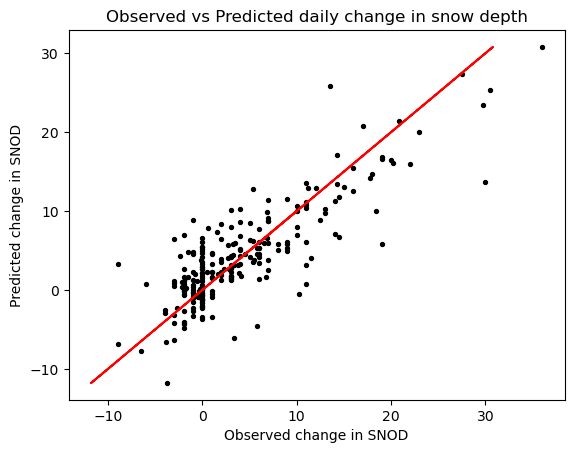

In [18]:
plt.scatter(y_accum_test_2, preds_accum, s = 8, c = "black")
plt.plot(preds_accum, preds_accum, c = "red")
plt.xlabel("Observed change in SNOD")
plt.ylabel("Predicted change in SNOD")
plt.title("Observed vs Predicted daily change in snow depth")
print("rmse = ", rmse_accum) 
print("r2 = ", r2_accum)

rmse =  2.5507120819588036
r2 =  0.8585837020250691


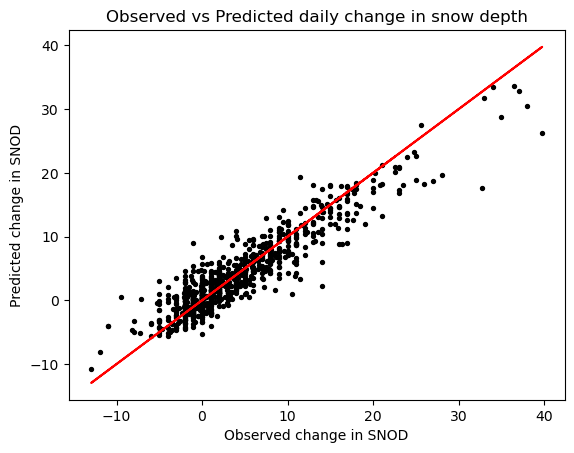

In [19]:
preds_accum_train = accum_backprop.predict(X_accum_fit_train)

preds_accum_train = scaler_y_accum.inverse_transform(preds_accum_train.reshape(-1,1))
y_accum_train_1 = scaler_y_accum.inverse_transform(np.array(y_accum_fit_train).reshape(-1,1))

rmse_accum_train = metrics.root_mean_squared_error(y_accum_train_1, preds_accum_train)
r2_accum_train = metrics.r2_score(y_accum_train_1, preds_accum_train)

plt.scatter(y_accum_train_1, preds_accum_train, s = 8, c = "black")
plt.plot(y_accum_train_1, y_accum_train_1, c = "red")
plt.xlabel("Observed change in SNOD")
plt.ylabel("Predicted change in SNOD")
plt.title("Observed vs Predicted daily change in snow depth")
print("rmse = ", rmse_accum_train) 
print("r2 = ", r2_accum_train)

In [11]:
def objective(trial):
        # Suggest hyperparameters for MLP
    hidden_layer_sizes = trial.suggest_categorical('hidden_layer_sizes', [(50), (100),(200), (100,100), (200,200)])
    alpha = trial.suggest_float('alpha', 1e-8, 1e-2, log = True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-8, 1e-2, log = True)
    tolerance = trial.suggest_float('tolerance', 1e-8, 1e-2, log = True)
    n_iter_no_change = trial.suggest_int('n_iter_no_change', 10, 200)

    kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
    fold_accuracies = []

    for train_index, val_index in kf.split(X_accum_fit):

        X_train = X_accum_fit.iloc[train_index]
        X_val = X_accum_fit.iloc[val_index]
        y_train = y_accum_fit[train_index]
        y_val = y_accum_fit[val_index]        

        # Create MLP model with suggested hyperparameters
        model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes,
                            activation='logistic',
                            solver='adam',
                            alpha=alpha,
                            learning_rate_init=learning_rate_init,
                            tol = tolerance,
                            n_iter_no_change = n_iter_no_change,
                            max_iter=2000, # Set a reasonable max_iter
                            random_state=42)

        # Train the model
        model.fit(X_train, y_train)

        # Evaluate the model
        preds_ablat = model.predict(X_val)
        preds_ablat = scaler_y_accum.inverse_transform(preds_ablat.reshape(-1,1))
        y_ablat_test_2 = scaler_y_accum.inverse_transform(np.array(y_val).reshape(-1,1))

        score = metrics.root_mean_squared_error(y_ablat_test_2, preds_ablat)
        fold_accuracies.append(score)

    return sum(fold_accuracies)/len(fold_accuracies) 

study = optuna.create_study(direction='minimize') # 'minimize' for error, 'maximize' for accuracy/score
study.optimize(objective, n_trials=100) # Run 50 trials

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_params}")


[I 2025-11-25 21:50:14,112] A new study created in memory with name: no-name-0e876b04-d7b3-4364-8f20-58a9e3cc2132


c:\Users\jrladue\AppData\Local\anaconda3\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 100) which is of type tuple.
  warnings.warn(message)
c:\Users\jrladue\AppData\Local\anaconda3\Lib\site-packages\optuna\distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (200, 200) which is of type tuple.
  warnings.warn(message)
c:\Users\jrladue\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\jrladue\AppData\Local\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (

Best trial: 4.014613694771336
Best hyperparameters: {'hidden_layer_sizes': 50, 'alpha': 0.003921386524837973, 'learning_rate_init': 0.0005821050248398088, 'tolerance': 3.179785211748248e-07, 'n_iter_no_change': 38}


In [18]:
optuna.visualization.plot_optimization_history(study)

In [20]:
explainer = shap.Explainer(accum_backprop.predict, X_accum_fit_train)
shap_values_train = explainer.shap_values(X_accum_fit_train)
shap_values_test = explainer.shap_values(X_accum_fit_test)
shap_values_full = explainer.shap_values(X_accum_fit)

PermutationExplainer explainer: 971it [00:56, 14.97it/s]                         
PermutationExplainer explainer: 244it [00:14,  4.91it/s]                         
PermutationExplainer explainer: 1214it [01:13, 14.24it/s]                          


In [24]:
shap_values_full_forest = shap_values_full[:,3:16]
X_forest = X_accum.iloc[:,3:16]

C:\Users\jrladue\AppData\Local\Temp\ipykernel_18520\2734873960.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full, X_accum, max_display = 35)


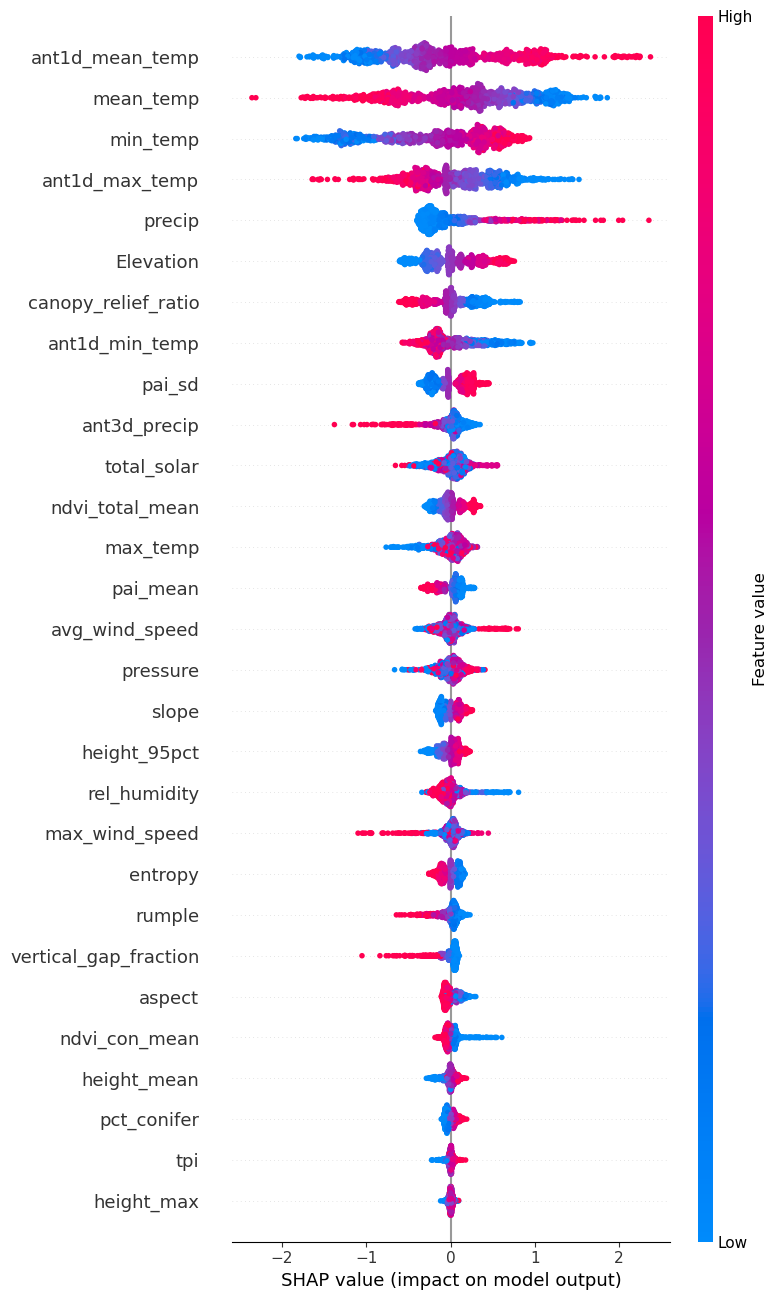

C:\Users\jrladue\AppData\Local\Temp\ipykernel_18520\2734873960.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full_forest, X_forest)


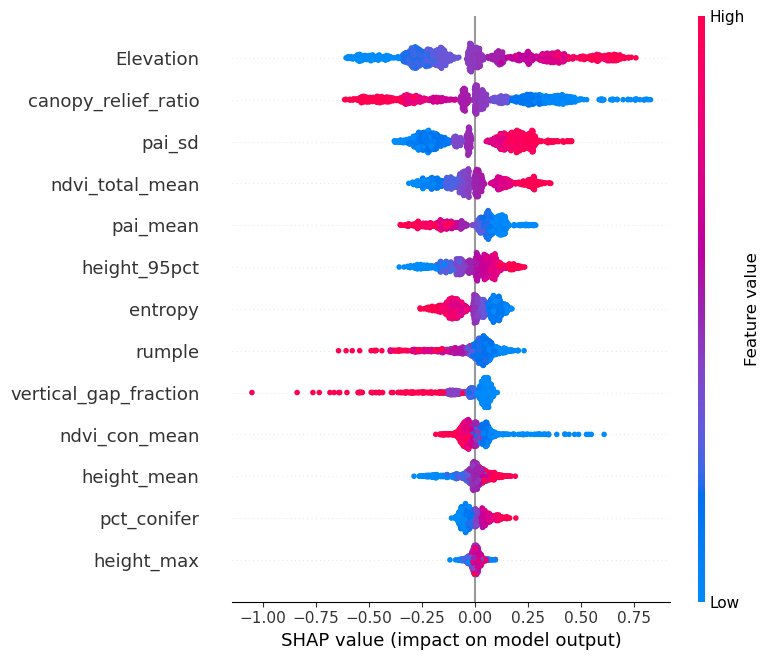

In [25]:
shap.summary_plot(shap_values_full, X_accum, max_display = 35)
shap.summary_plot(shap_values_full_forest, X_forest)

In [81]:
explanation = explainer(X_accum_fit)

PermutationExplainer explainer: 1214it [03:34,  5.38it/s]                          


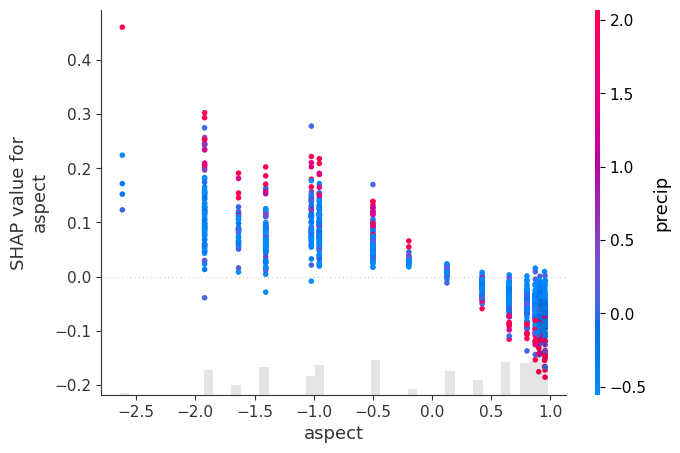

In [110]:
shap.plots.scatter(explanation[:,1], color = explanation)

(array([ 20.,  57., 339., 660., 130.,  13.,   0.,   0.,   0.,   2.]),
 array([-3.77872294, -2.60894177, -1.4391606 , -0.26937942,  0.90040175,
         2.07018292,  3.23996409,  4.40974527,  5.57952644,  6.74930761,
         7.91908879]),
 <BarContainer object of 10 artists>)

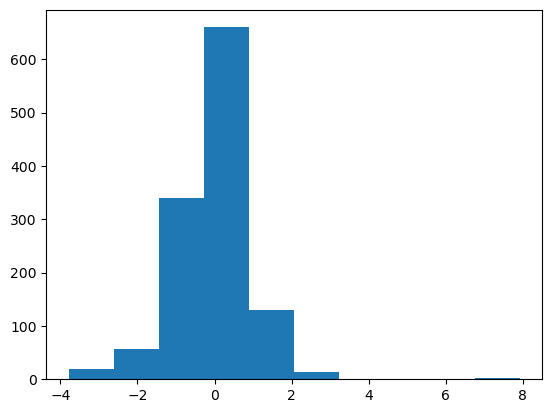

In [112]:
plt.hist(y_ablat_fit)